In [1]:
pip install pandas numpy matplotlib

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Better looking plots
sns.set_style("whitegrid")

In [10]:
import pandas as pd
import numpy as np


import zipfile

with zipfile.ZipFile('titanic.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

df = pd.read_csv("train.csv")
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
# Fill Age with median
df["Age"].fillna(df["Age"].median(), inplace=True)

# Fill Embarked with mode
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop Cabin because it has too many missing values
df.drop(columns=["Cabin"], inplace=True)

/tmp/ipykernel_858/1269732047.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_858/1269732047.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


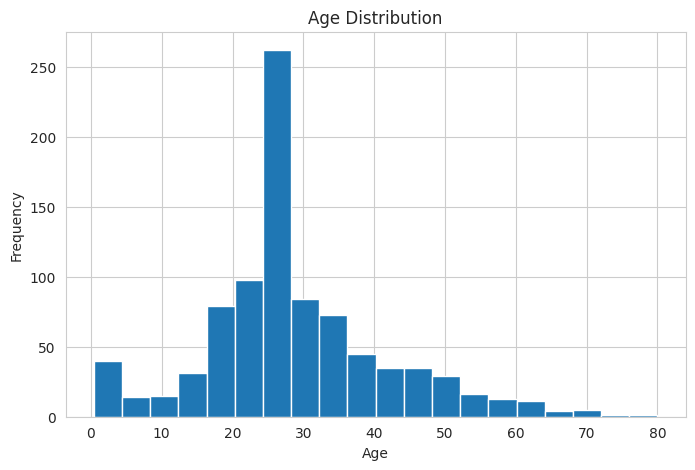

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

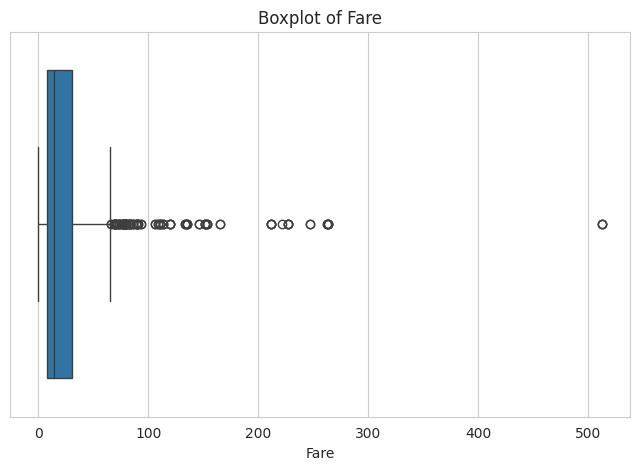

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Boxplot of Fare")
plt.show()

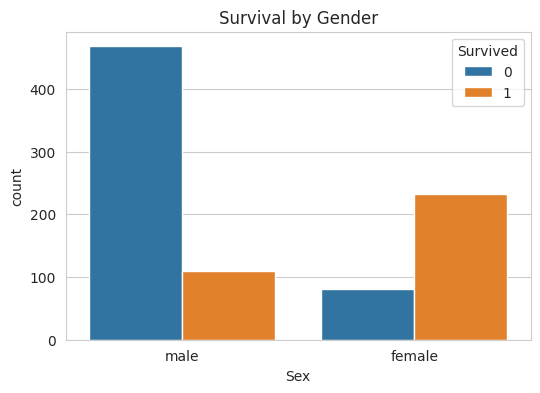

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

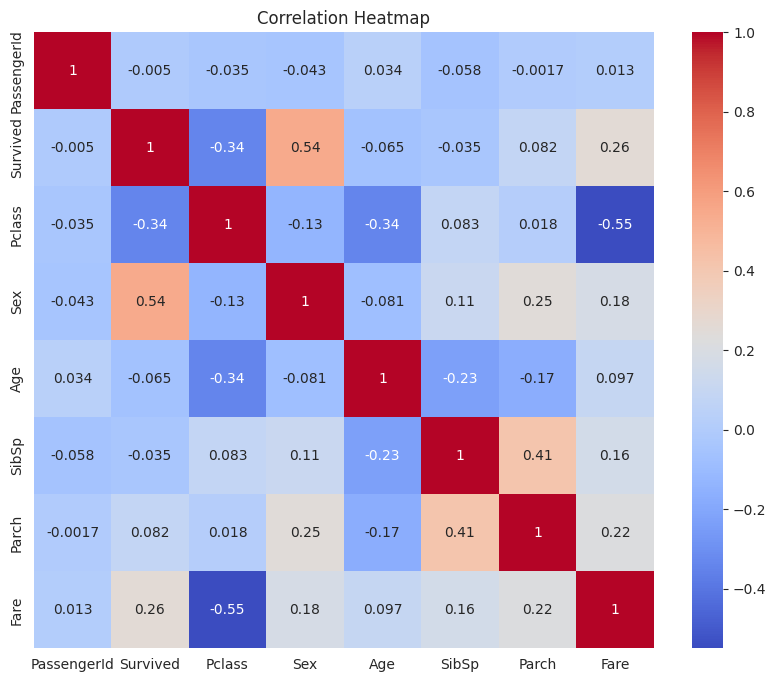

In [16]:
df_heatmap = df.copy()

df_heatmap["Sex"] = df_heatmap["Sex"].map({"male":0,"female":1})

corr = df_heatmap.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

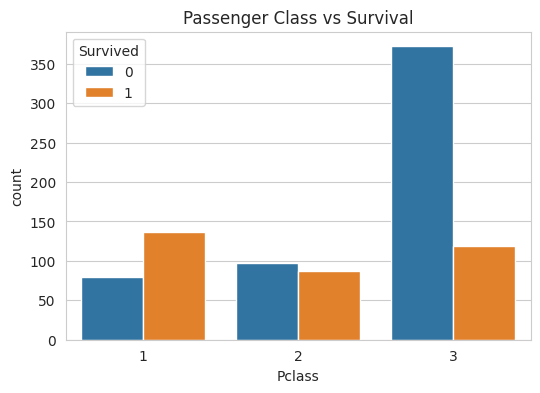

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Passenger Class vs Survival")
plt.show()

Based on the visualizations, I believe Sex has the strongest effect on survival. The bar chart shows that a much larger proportion of female passengers survived compared to male passengers. Passenger class (Pclass) also appears to influence survival, as first-class passengers had higher survival rates than those in third class. These patterns suggest that gender and socioeconomic status played significant roles in determining survival during the disaster.